# Kiper vs Reality — How accurate are post-draft grades?

This notebook compares post-draft team grades from various analysts (sourced from the Football Outsiders / FTN Draft Report Card Report pages) against an "actual" team draft grade computed from player career outcomes.

**Data caveat (important):** The Football Outsiders Report Card pages publish only the *highest* and *lowest* analyst grade per team plus a consensus GPA — not the full per-team × per-analyst grid. Each named analyst (including Kiper) appears in only ~3-5 rows per year (the teams where they were the high or low). Headline correlations are computed on this sparse sample.

**Years with Report Card data:** 2011, 2012, 2013, 2014, 2016, 2017, 2020, 2021, 2024 (9 of 15 years).
**Years missing (Wayback or live 404):** 2015, 2018, 2019, 2022, 2023, 2025.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")

comparison = pd.read_parquet("../data/processed/comparison.parquet")
team_outcomes = pd.read_parquet("../data/processed/team_outcomes.parquet")
analyst_grades = pd.read_parquet("../data/processed/analyst_grades.parquet")
print(f"comparison: {len(comparison):,} rows")
print(f"team_outcomes: {len(team_outcomes):,} rows")
print(f"analyst_grades: {len(analyst_grades):,} rows; analysts: {sorted(analyst_grades['analyst'].unique()) if len(analyst_grades) else '(none)'}")


comparison: 151 rows
team_outcomes: 480 rows
analyst_grades: 193 rows; analysts: ['Benoit', 'Davis', 'Dunleavy', 'Easterling', 'Edholm', 'Farrar', 'Iyer', 'Kadar', 'Kiper', 'Maske', 'PFF', 'Prisco', 'Reuter', 'Rill', 'Silva', 'Slater', 'Tagliere', 'Winks']


## Headline: how does each analyst correlate with reality?

In [2]:
full = comparison.query("eval_completeness == 'full'")
results = []
for analyst in sorted(full["analyst"].unique()):
    sub = full[full["analyst"] == analyst]
    if len(sub) < 3:
        continue
    pearson = stats.pearsonr(sub["analyst_grade_z"], sub["actual_grade_z"])
    spearman = stats.spearmanr(sub["analyst_grade_z"], sub["actual_grade_z"])
    results.append({
        "analyst": analyst,
        "n": len(sub),
        "pearson_r": pearson.statistic,
        "pearson_p": pearson.pvalue,
        "spearman_rho": spearman.statistic,
        "spearman_p": spearman.pvalue,
    })
leaderboard = pd.DataFrame(results).sort_values("pearson_r", ascending=False)
leaderboard


,analyst,n,pearson_r,pearson_p,spearman_rho,spearman_p
1,Easterling,4,0.826885,0.173115,0.800000,0.200000
12,Tagliere,7,0.757231,0.048695,0.954994,0.000806
6,Kiper,7,0.686607,0.088426,0.037062,0.937124
5,Kadar,3,0.588681,0.599295,0.500000,0.666667
4,Iyer,18,0.368023,0.132939,0.362042,0.139845
2,Edholm,5,0.306093,0.616444,0.051299,0.934713
0,Davis,10,0.217206,0.546650,0.090909,0.802772
9,Prisco,9,0.107430,0.783240,0.263890,0.492636
10,Reuter,16,0.093484,0.730576,0.190921,0.478762
11,Silva,13,0.038085,0.901692,-0.052706,0.864222


## Kiper specifically — scatter against reality

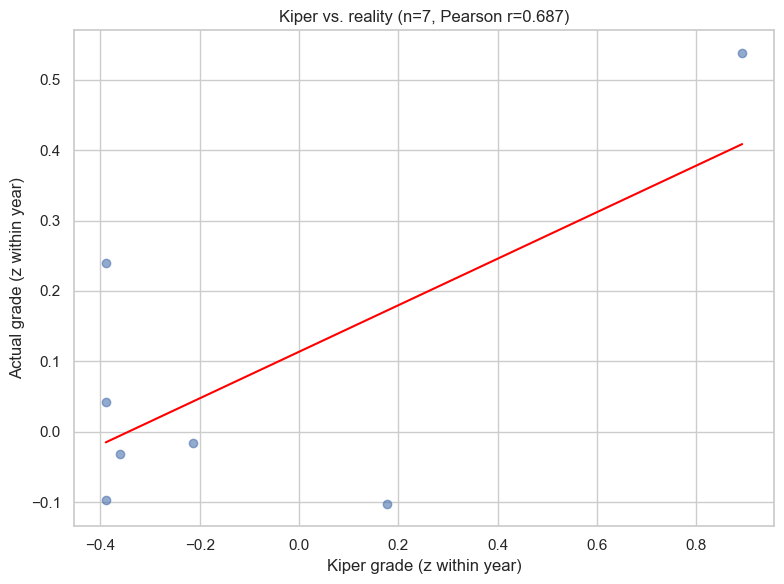

In [3]:
kiper = full[full["analyst"] == "Kiper"]
if len(kiper) >= 3:
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(kiper["analyst_grade_z"], kiper["actual_grade_z"], alpha=0.6)
    if len(kiper) >= 2:
        m, b = np.polyfit(kiper["analyst_grade_z"], kiper["actual_grade_z"], 1)
        xs = np.linspace(kiper["analyst_grade_z"].min(), kiper["analyst_grade_z"].max(), 50)
        ax.plot(xs, m * xs + b, color="red")
    r_val = leaderboard.set_index("analyst").loc["Kiper", "pearson_r"] if "Kiper" in leaderboard["analyst"].values else float("nan")
    ax.set_xlabel("Kiper grade (z within year)")
    ax.set_ylabel("Actual grade (z within year)")
    ax.set_title(f"Kiper vs. reality (n={len(kiper)}, Pearson r={r_val:.3f})")
    plt.tight_layout()
else:
    print(f"Only {len(kiper)} Kiper rows — too few for a meaningful scatter")


## Kiper, by year

In [4]:
def yearly_pearson(g):
    if len(g) < 3:
        return None
    return stats.pearsonr(g["analyst_grade_z"], g["actual_grade_z"]).statistic

if "Kiper" in full["analyst"].unique():
    by_year = (
        full[full["analyst"] == "Kiper"]
        .groupby("draft_year")
        .apply(yearly_pearson, include_groups=False)
        .reset_index(name="pearson_r")
    )
    print(by_year)
else:
    print("No Kiper rows in full-eval comparison")


   draft_year  pearson_r
0        2017   0.865294
1        2020        NaN
2        2021        NaN


## Biggest Kiper misses (largest |residual|)

In [5]:
if "Kiper" in full["analyst"].unique():
    misses = full[full["analyst"] == "Kiper"].copy()
    misses["abs_residual"] = misses["residual"].abs()
    misses = misses.sort_values("abs_residual", ascending=False).head(20)
    print(misses[["draft_year", "team", "analyst_grade_z", "actual_grade_z", "actual_grade_letter", "residual"]].to_string())
else:
    print("No Kiper rows in full-eval comparison")


    draft_year team  analyst_grade_z  actual_grade_z actual_grade_letter  residual
36        2017  CHI        -0.389086        0.239256                  B+  0.628342
21        2017  SEA        -0.389086        0.041944                  B+  0.431030
13        2017  BUF         0.892610        0.538092                  A- -0.354518
50        2020  DEN        -0.360410       -0.032166                   B  0.328244
12        2017  MIA        -0.389086       -0.097387                   B  0.291700
42        2020  ARI         0.176371       -0.102276                   B -0.278647
93        2021  CLE        -0.213492       -0.015569                   B  0.197923


## Team outcome distribution

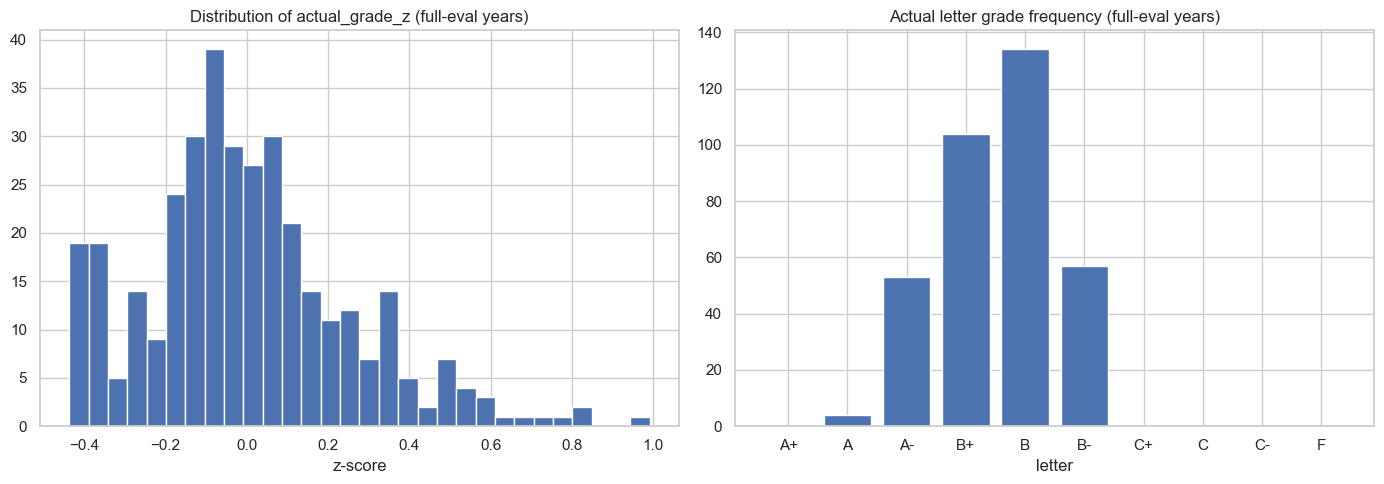

In [6]:
full_outcomes = team_outcomes.query("eval_completeness == 'full'")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(full_outcomes["actual_grade_z"].dropna(), bins=30)
axes[0].set_title("Distribution of actual_grade_z (full-eval years)")
axes[0].set_xlabel("z-score")

# Letter grade frequencies
letter_order = ["A+", "A", "A-", "B+", "B", "B-", "C+", "C", "C-", "F"]
counts = full_outcomes["actual_grade_letter"].value_counts().reindex(letter_order, fill_value=0)
axes[1].bar(counts.index, counts.values)
axes[1].set_title("Actual letter grade frequency (full-eval years)")
axes[1].set_xlabel("letter")
plt.tight_layout()
